# **1D-CNN AE**

## **1. 드라이브 연결**

In [6]:
from google.colab import drive
import os

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **2. 파라미터 설정, 데이터 로드, 데이터셋 분리**

- 실험 별로 나누어서 데이터셋 구성

In [7]:
# ==========================================
# 1. 라이브러리 및 환경 설정 (필수)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, f1_score
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
import warnings


# ==========================================
# 2. 데이터 로드
# ==========================================
file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx"

if os.path.exists(file_path):
    print(f"Loading data from: {file_path}")
    if file_path.endswith('.xlsx'):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path)
else:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    df = pd.DataFrame()

# 센서 컬럼 정의
sensor_cols = [
    'BCl3 Flow', 'Cl2 Flow', 'RF Btm Pwr', 'RF Btm Rfl Pwr', 'Endpt A',
    'He Press', 'Pressure', 'RF Tuner', 'RF Load', 'RF Phase Err',
    'RF Pwr', 'RF Impedance', 'TCP Tuner', 'TCP Phase Err',
    'TCP Impedance', 'TCP Top Pwr', 'TCP Rfl Pwr', 'TCP Load', 'Vat Valve'
]

# ==========================================
# 3. 데이터 전처리 함수
# ==========================================
"""
    Wafer_ID 별로 슬라이딩 윈도우를 적용하고,
    각 윈도우가 어떤 Wafer에 속하는지 ID 리스트를 함께 반환합니다.
"""
def create_sequences_with_ids(df_target, wafer_col, sensor_cols, seq_len, scaler=None, is_train=True):

    # 1. 데이터 추출
    data_values = df_target[sensor_cols].values

    # 2. 스케일링 (Train 통계로만 Scale)
    if is_train:
        if scaler is None:
            scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(data_values)
    else:
        if scaler is None:
            raise ValueError("Test mode requires a fitted scaler from training data.")
        data_scaled = scaler.transform(data_values)

    # 스케일링된 데이터를 다시 DataFrame으로 매핑 (ID 그룹핑 용도)
    df_scaled = pd.DataFrame(data_scaled, columns=sensor_cols, index=df_target.index)
    df_scaled[wafer_col] = df_target[wafer_col].values

    all_sequences = []
    all_wafer_ids = [] # [NEW] 각 윈도우의 소스 Wafer ID를 저장할 리스트

    unique_wafers = df_scaled[wafer_col].unique()

    for wafer in unique_wafers:
        # 특정 Wafer 데이터 추출
        wafer_data = df_scaled[df_scaled[wafer_col] == wafer][sensor_cols].values

        # 데이터 길이가 윈도우보다 작으면 스킵
        if len(wafer_data) < seq_len:
            continue

        # 슬라이딩 윈도우 생성
        for i in range(len(wafer_data) - seq_len + 1):
            window = wafer_data[i : i + seq_len]

            all_sequences.append(window)
            all_wafer_ids.append(wafer) # [NEW] 현재 윈도우의 Wafer ID 저장

    if len(all_sequences) == 0:
        return np.array([]), np.array([]), scaler

    return np.array(all_sequences), np.array(all_wafer_ids), scaler

# ==========================================
# 4. 데이터셋 구성 및 저장
# ==========================================
experiments = ['l29', 'l31', 'l33']
datasets = {}
SEQ_LEN = 32

# 학습 데이터 비율 설정
TRAIN_RATIO = 0.6

print(f"\n--- Preprocessing Data (Train Ratio: {TRAIN_RATIO*100}%) ---")

for exp_id in experiments:
    print(f"\nProcessing Experiment: {exp_id}")

    # 1. 실험 데이터 필터링
    exp_df = df[df['Wafer_ID'].str.contains(exp_id, case=False, na=False)]
    if exp_df.empty:
        continue

    # 2. Train / Test Split (Wafer ID 기준)
    normal_wafer_ids = exp_df[exp_df['Label'] == 'Normal']['Wafer_ID'].unique()
    fault_wafer_ids = exp_df[exp_df['Label'] == 'Fault']['Wafer_ID'].unique()

    # [수정] 비율 적용 (Normal Wafer만 분할)
    n_train = int(len(normal_wafer_ids) * TRAIN_RATIO)

    train_ids = normal_wafer_ids[:n_train]
    test_norm_ids = normal_wafer_ids[n_train:]

    # ID 기반 데이터프레임 분할
    train_df = exp_df[exp_df['Wafer_ID'].isin(train_ids)]
    test_norm_df = exp_df[exp_df['Wafer_ID'].isin(test_norm_ids)]
    test_fault_df = exp_df[exp_df['Wafer_ID'].isin(fault_wafer_ids)]

    print(f"  - Total Normal: {len(normal_wafer_ids)}")
    print(f"  -> Train Normal : {len(train_ids)} ({TRAIN_RATIO*100:.0f}%)")
    print(f"  -> Test Normal  : {len(test_norm_ids)} ({(1-TRAIN_RATIO)*100:.0f}%)")
    print(f"  -> Test Fault   : {len(fault_wafer_ids)} (100%)")

    # 3. 시퀀스 생성 (X, Wafer_ID 반환)
    # (1) Train: Scaler 학습 (Fit)
    X_train, y_train_ids, scaler = create_sequences_with_ids(
        train_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=None, is_train=True
    )

    # (2) Test Normal: Scaler 적용 (Transform)
    X_test_norm, y_test_norm_ids, _ = create_sequences_with_ids(
        test_norm_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=scaler, is_train=False
    )

    # (3) Test Fault: Scaler 적용 (Transform)
    if not test_fault_df.empty:
        X_test_fault, y_test_fault_ids, _ = create_sequences_with_ids(
            test_fault_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=scaler, is_train=False
        )
    else:
        X_test_fault, y_test_fault_ids = np.array([]), np.array([])

    # 4. Dictionary에 저장
    datasets[exp_id] = {
        'X_train': X_train,
        'X_test_norm': X_test_norm,
        'X_test_fault': X_test_fault,
        'ids_train': y_train_ids,
        'ids_test_norm': y_test_norm_ids,
        'ids_test_fault': y_test_fault_ids,
        'scaler': scaler
    }

print("\n✅ Data preprocessing with new ratio completed.")

Loading data from: /content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx

--- Preprocessing Data (Train Ratio: 60.0%) ---

Processing Experiment: l29
  - Total Normal: 34
  -> Train Normal : 20 (60%)
  -> Test Normal  : 14 (40%)
  -> Test Fault   : 9 (100%)

Processing Experiment: l31
  - Total Normal: 37
  -> Train Normal : 22 (60%)
  -> Test Normal  : 15 (40%)
  -> Test Fault   : 6 (100%)

Processing Experiment: l33
  - Total Normal: 37
  -> Train Normal : 22 (60%)
  -> Test Normal  : 15 (40%)
  -> Test Fault   : 6 (100%)

✅ Data preprocessing with new ratio completed.


## **3. 함수 정의**

In [8]:
# ==========================================
# 3. 유틸리티 함수 (데이터 로드, 집계, 시각화)
# ==========================================
def get_data_loaders(exp_id, datasets_dict, batch_size=32):
    print(f"\n📊 [Data Setup] Experiment: {exp_id}")
    data = datasets_dict[exp_id]

    # 데이터 추출
    X_train = data['X_train']
    X_test_norm = data['X_test_norm']
    ids_test_norm = data['ids_test_norm']
    X_test_fault = data['X_test_fault']
    ids_test_fault = data['ids_test_fault']

    # Tensor 변환
    train_tensor = torch.FloatTensor(X_train).to(device)
    test_norm_tensor = torch.FloatTensor(X_test_norm).to(device)

    if len(X_test_fault) > 0:
        test_fault_tensor = torch.FloatTensor(X_test_fault).to(device)
    else:
        test_fault_tensor = torch.FloatTensor([]).to(device)

    # DataLoader (Train only)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    return train_loader, (test_norm_tensor, ids_test_norm), (test_fault_tensor, ids_test_fault)

def aggregate_wafer_scores(window_scores, wafer_ids, method='max'):
    # DataFrame핑하여 GroupBy 연산
    df_temp = pd.DataFrame({'Wafer_ID': wafer_ids, 'Score': window_scores})

    if method == 'max':
        grouped = df_temp.groupby('Wafer_ID')['Score'].max()
    else:
        grouped = df_temp.groupby('Wafer_ID')['Score'].mean()

    return grouped.index.values, grouped.values

def visualize_results(model_name, exp_id, scores, labels, threshold):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plt.suptitle(f"[{exp_id}] {model_name} Performance (Wafer-Level)", fontsize=16, fontweight='bold')

    # Confusion Matrix
    preds = (scores > threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=['Normal', 'Fault'], yticklabels=['Normal', 'Fault'])
    axes[0].set_title("Confusion Matrix")

    # Scatter Plot (Wafer Scores)
    normal_idx = np.where(labels == 0)[0]
    fault_idx = np.where(labels == 1)[0]

    axes[1].scatter(normal_idx, scores[normal_idx], color='blue', label='Normal', alpha=0.6, s=20)
    axes[1].scatter(fault_idx, scores[fault_idx], color='red', label='Fault', alpha=0.6, s=20)
    axes[1].axhline(y=threshold, color='green', linestyle='--', label='Threshold')
    axes[1].set_title("Wafer Anomaly Scores")
    axes[1].legend()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[2].set_title("ROC Curve")
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def evaluate_performance_fixed_threshold(model_name, exp_id, scores, labels, threshold):
    # 1. 고정된 임계값을 기준으로 이상 여부 판별 (크면 1: Fault, 작으면 0: Normal)
    preds = (scores > threshold).astype(int)

    # 2. F1-Score 계산 (더 이상 최적의 값을 찾지 않음)
    f1 = f1_score(labels, preds)

    # 3. AUROC 계산 (AUC는 임계값과 무관하게 모델의 분류 잠재력을 보여줌)
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    print(f"\n📌 [{model_name} - {exp_id}] Wafer-Level Summary (Unsupervised)")
    print(f"   - AUROC          : {roc_auc:.4f}")
    print(f"   - F1-Score       : {f1:.4f} (at Fixed Threshold: {threshold:.6f})")

    # 시각화 함수 호출
    visualize_results(model_name, exp_id, scores, labels, threshold)

    return roc_auc, f1

## **4. 모델 구현**

In [9]:
import torch
import torch.nn as nn

class CNN1D_AE(nn.Module):
    def __init__(self, num_sensors=19, seq_len=32, latent_dim=8):
        super(CNN1D_AE, self).__init__()

        # 논문 권장사항: 작은 Kernel Size 선호
        # 모델 경량화 및 seq_len=32를 고려하여 kernel_size=3, stride=2 사용

        # ---------------------------
        # Encoder (차원 축소)
        # ---------------------------
        self.encoder = nn.Sequential(
            # Input: (Batch, 19, 32) -> Output: (Batch, 32, 16)
            nn.Conv1d(in_channels=num_sensors, out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(), # 각 레이어마다 ReLU 적용

            # Input: (Batch, 32, 16) -> Output: (Batch, 16, 8)
            nn.Conv1d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            # Input: (Batch, 16, 8) -> Output: (Batch, latent_dim, 4)
            nn.Conv1d(in_channels=16, out_channels=latent_dim, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        # ---------------------------
        # Decoder (대칭적 복원 )
        # ---------------------------
        self.decoder = nn.Sequential(
            # Input: (Batch, latent_dim, 4) -> Output: (Batch, 16, 8)
            nn.ConvTranspose1d(in_channels=latent_dim, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Input: (Batch, 16, 8) -> Output: (Batch, 32, 16)
            nn.ConvTranspose1d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Input: (Batch, 32, 16) -> Output: (Batch, 19, 32)
            # 마지막 레이어는 입력 데이터의 스케일(MinMax, 0~1)에 맞춰 Sigmoid를 적용하거나 생략할 수 있습니다.
            nn.ConvTranspose1d(in_channels=32, out_channels=num_sensors, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 🚨 중요: 이전 단계에서 언급했던 차원 변환 (Batch, Seq_Len, Sensors) -> (Batch, Sensors, Seq_Len)
        x = x.transpose(1, 2)

        latent = self.encoder(x)
        reconstructed = self.decoder(latent)

        # 출력 시 다시 원래 형태로 복구 (Batch, Seq_Len, Sensors)
        return reconstructed.transpose(1, 2)



import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

def train_1d_cnn_ae(model, train_loader, optimizer, epoch, device):
    model.train()
    total_loss = 0
    criterion = nn.L1Loss() # MAE Loss

    for (data,) in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        # AE는 자기 자신을 타겟으로 복원
        output = model(data)
        loss = criterion(output, data)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 10 == 0: # 에포크가 많으므로 10단위 출력
        print(f"Epoch [{epoch+1}] Loss: {avg_loss:.4f}")
    return avg_loss

def calculate_window_scores_1d_cnn(model, data_tensor, device, batch_size=32):
    model.eval()
    all_scores = []
    criterion = nn.L1Loss(reduction='none')

    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            output = model(data)

            # Element-wise MAE Loss: (Batch, Seq_Len, Num_Sensors)
            loss_element = criterion(output, data)

            # [논문 반영] Localised Reconstruction Error (LRE)
            # 1. 채널별(byChannel) 시간축 평균 에러 계산 -> (Batch, Num_Sensors)
            channel_errors = loss_element.mean(dim=1)
            # 2. 센서 중 가장 높은 오차값을 윈도우 스코어로 사용 -> (Batch)
            score_window, _ = channel_errors.max(dim=1)

            all_scores.extend(score_window.cpu().numpy())

    return np.array(all_scores)

## **5. 학습 및 추론**

Using device: cuda

>>> Running 1D-CNN AE on Experiment: l29

📊 [Data Setup] Experiment: l29
Training started...
Epoch [10] Loss: 0.1121
Epoch [20] Loss: 0.0842
Epoch [30] Loss: 0.0823
Epoch [40] Loss: 0.0814
Epoch [50] Loss: 0.0808
Calculating Train Scores for Thresholding...
   * Train Score Mean: 0.3314, Std: 0.0627
   * Fixed 3-Sigma Threshold: 0.5195
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [1D-CNN AE - l29] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.7698
   - F1-Score       : 0.5000 (at Fixed Threshold: 0.519479)


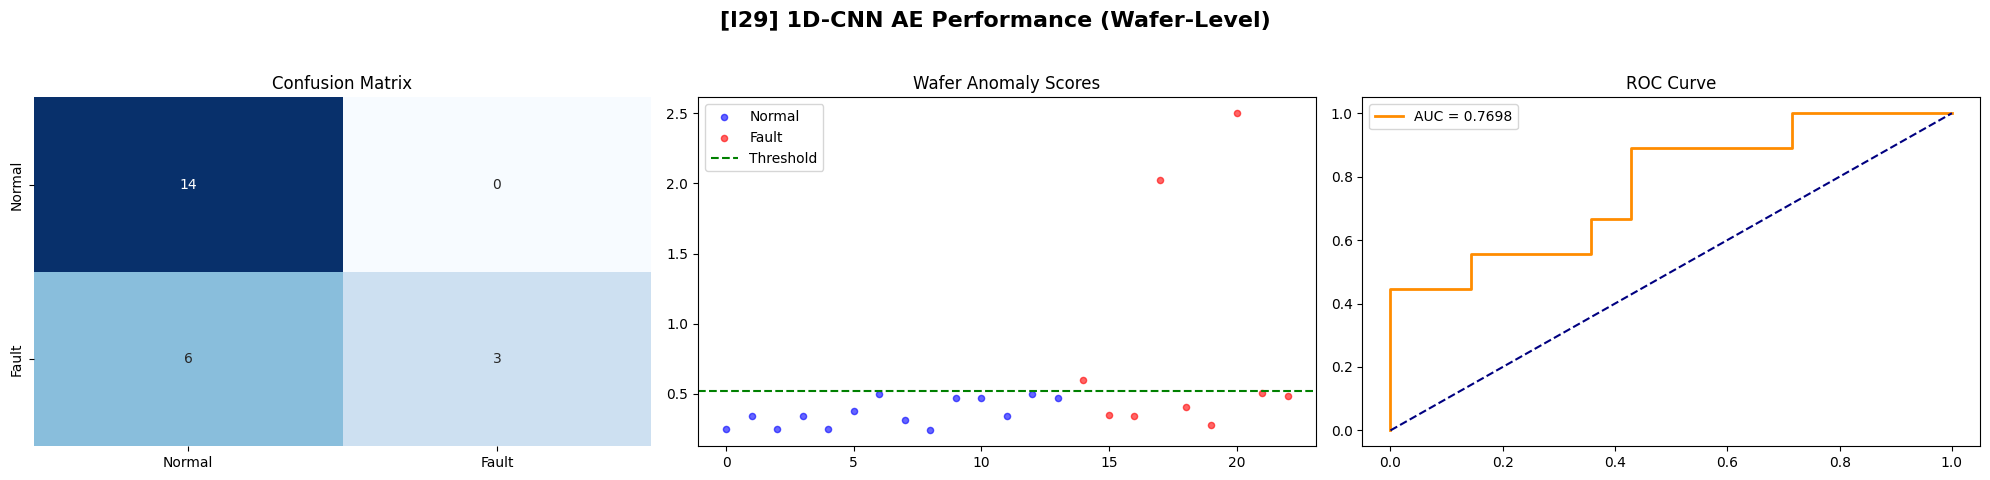


>>> Running 1D-CNN AE on Experiment: l31

📊 [Data Setup] Experiment: l31
Training started...
Epoch [10] Loss: 0.1257
Epoch [20] Loss: 0.0852
Epoch [30] Loss: 0.0819
Epoch [40] Loss: 0.0807
Epoch [50] Loss: 0.0800
Calculating Train Scores for Thresholding...
   * Train Score Mean: 0.2467, Std: 0.0318
   * Fixed 3-Sigma Threshold: 0.3420
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [1D-CNN AE - l31] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.9222
   - F1-Score       : 0.8000 (at Fixed Threshold: 0.341998)


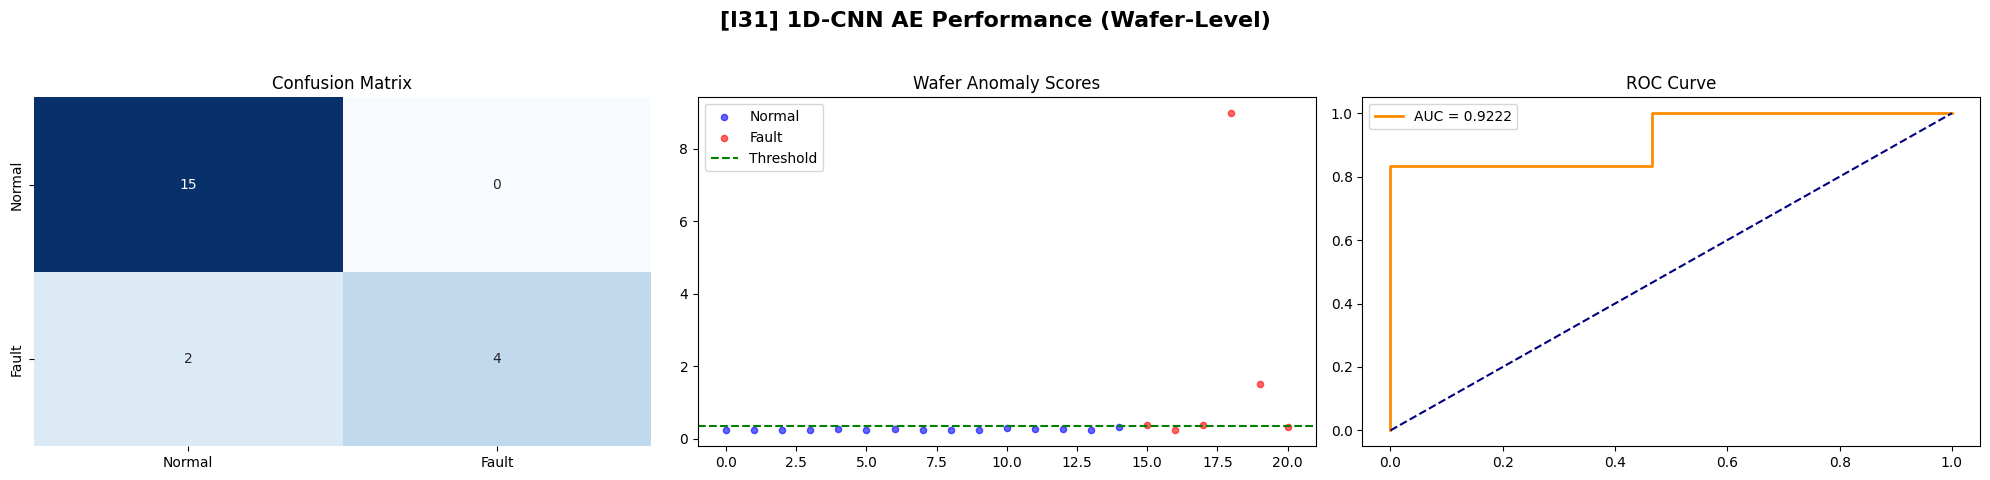


>>> Running 1D-CNN AE on Experiment: l33

📊 [Data Setup] Experiment: l33
Training started...
Epoch [10] Loss: 0.0973
Epoch [20] Loss: 0.0835
Epoch [30] Loss: 0.0819
Epoch [40] Loss: 0.0804
Epoch [50] Loss: 0.0795
Calculating Train Scores for Thresholding...
   * Train Score Mean: 0.2363, Std: 0.0249
   * Fixed 3-Sigma Threshold: 0.3111
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [1D-CNN AE - l33] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.6556
   - F1-Score       : 0.4211 (at Fixed Threshold: 0.311106)


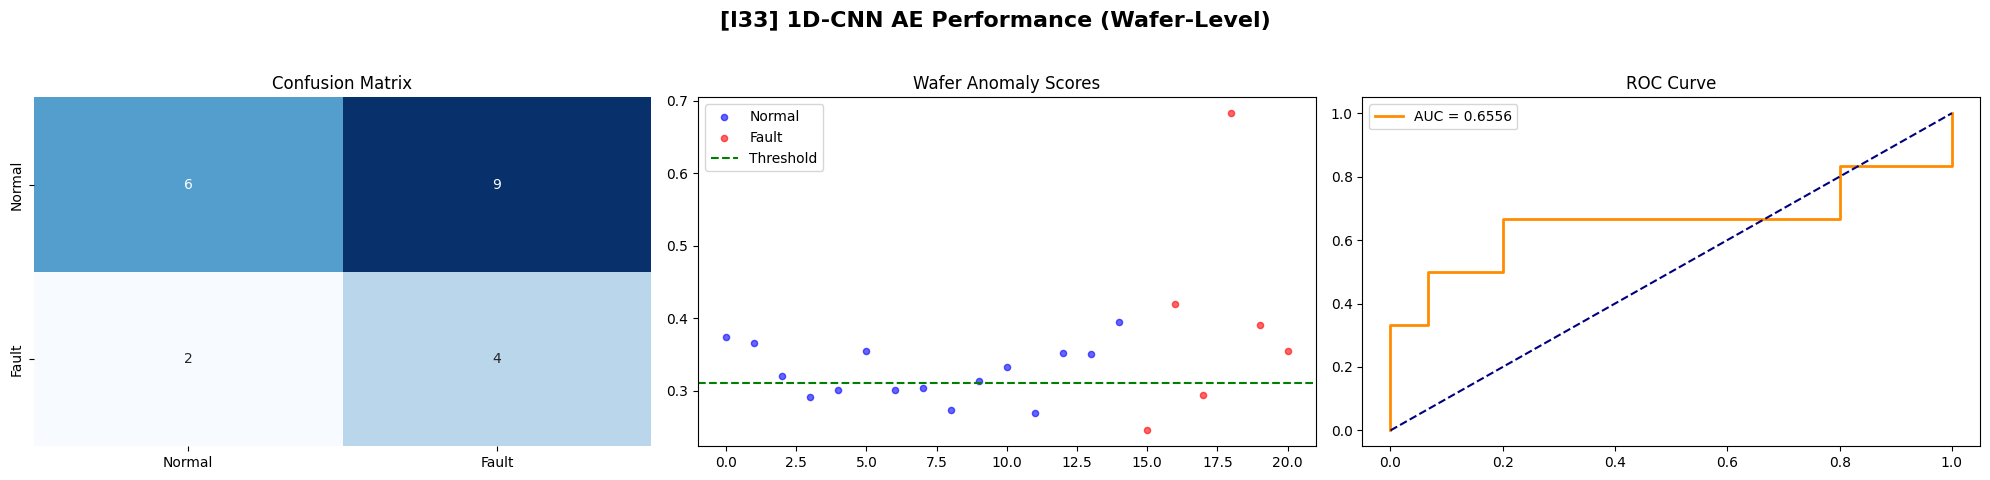


✅ All experiments finished.
{'l29': {'AUC': np.float64(0.7698412698412699), 'F1': 0.5}, 'l31': {'AUC': np.float64(0.9222222222222223), 'F1': 0.8}, 'l33': {'AUC': np.float64(0.6555555555555554), 'F1': 0.42105263157894735}}


In [10]:
# ==========================================
# 5. 메인 실행 루프 (1D-CNN AE + 3-Sigma Threshold)
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1D-CNN AE 하이퍼파라미터
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
LATENT_DIM = 8  # 병목 구간(Bottleneck) 차원 수
SIGMA_MULTIPLIER = 3 # 3-Sigma 임계값 설정용

results = {}
target_experiments = ['l29', 'l31', 'l33']

for exp_id in target_experiments:
    if exp_id not in datasets:
        print(f"Skipping {exp_id}: Dataset not found.")
        continue

    print(f"\n>>> Running 1D-CNN AE on Experiment: {exp_id}")

    # 1. 데이터 로드
    train_loader, (test_norm, ids_norm), (test_fault, ids_fault) = get_data_loaders(exp_id, datasets, BATCH_SIZE)

    # 2. 모델 초기화
    num_sensors = test_norm.shape[2]
    seq_len_input = test_norm.shape[1] # 32 (그대로 사용)

    model = CNN1D_AE(
        num_sensors=num_sensors,
        seq_len=seq_len_input,
        latent_dim=LATENT_DIM
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 3. 학습
    print("Training started...")
    for epoch in range(NUM_EPOCHS):
        train_1d_cnn_ae(model, train_loader, optimizer, epoch, device)

    # -----------------------------------------------------------
    # 4. 임계값(Threshold) 설정 (Train 데이터 통계치 활용)
    # -----------------------------------------------------------
    print("Calculating Train Scores for Thresholding...")
    train_tensor = train_loader.dataset.tensors[0]

    # TRACE-GPT 함수 대신 1D-CNN AE 전용 스코어 계산 함수 호출
    train_window_scores = calculate_window_scores_1d_cnn(model, train_tensor, device, BATCH_SIZE)

    ids_train = datasets[exp_id]['ids_train']
    _, train_wafer_scores = aggregate_wafer_scores(train_window_scores, ids_train, method='max')

    train_mean = np.mean(train_wafer_scores)
    train_std = np.std(train_wafer_scores)

    fixed_threshold = train_mean + (SIGMA_MULTIPLIER * train_std)

    print(f"   * Train Score Mean: {train_mean:.4f}, Std: {train_std:.4f}")
    print(f"   * Fixed {SIGMA_MULTIPLIER}-Sigma Threshold: {fixed_threshold:.4f}")

    # -----------------------------------------------------------
    # 5. 추론 (Test Data Window Score)
    # -----------------------------------------------------------
    print("Calculating Test Window Scores...")
    norm_window_scores = calculate_window_scores_1d_cnn(model, test_norm, device, BATCH_SIZE)

    if len(test_fault) > 0:
        fault_window_scores = calculate_window_scores_1d_cnn(model, test_fault, device, BATCH_SIZE)
    else:
        fault_window_scores = np.array([])

    # -----------------------------------------------------------
    # 6. 집계 (Wafer Aggregation)
    # -----------------------------------------------------------
    print("Aggregating Test Wafer Scores...")
    _, norm_wafer_scores = aggregate_wafer_scores(norm_window_scores, ids_norm, method='max')
    norm_labels = np.zeros(len(norm_wafer_scores))

    if len(fault_window_scores) > 0:
        _, fault_wafer_scores = aggregate_wafer_scores(fault_window_scores, ids_fault, method='max')
        fault_labels = np.ones(len(fault_wafer_scores))
    else:
        fault_wafer_scores = np.array([])
        fault_labels = np.array([])

    final_scores = np.concatenate([norm_wafer_scores, fault_wafer_scores])
    final_labels = np.concatenate([norm_labels, fault_labels])

    # -----------------------------------------------------------
    # 7. 평가 (고정 임계값 기반)
    # -----------------------------------------------------------
    auc_score, f1 = evaluate_performance_fixed_threshold(
        "1D-CNN AE", exp_id, final_scores, final_labels, fixed_threshold
    )
    results[exp_id] = {'AUC': auc_score, 'F1': f1}

print("\n✅ All experiments finished.")
print(results)

# **TRACE-GPT**

## **2. 파라미터 설정, 데이터 로드, 데이터셋 분리**

- 실험 별로 나누어서 데이터셋 구성

In [11]:
# ==========================================
# 1. 라이브러리 및 환경 설정 (필수)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, f1_score
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
import warnings


# ==========================================
# 2. 데이터 로드
# ==========================================
file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx"

if os.path.exists(file_path):
    print(f"Loading data from: {file_path}")
    if file_path.endswith('.xlsx'):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path)
else:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    df = pd.DataFrame()

# 센서 컬럼 정의
sensor_cols = [
    'BCl3 Flow', 'Cl2 Flow', 'RF Btm Pwr', 'RF Btm Rfl Pwr', 'Endpt A',
    'He Press', 'Pressure', 'RF Tuner', 'RF Load', 'RF Phase Err',
    'RF Pwr', 'RF Impedance', 'TCP Tuner', 'TCP Phase Err',
    'TCP Impedance', 'TCP Top Pwr', 'TCP Rfl Pwr', 'TCP Load', 'Vat Valve'
]

# ==========================================
# 3. 데이터 전처리 함수
# ==========================================
"""
    Wafer_ID 별로 슬라이딩 윈도우를 적용하고,
    각 윈도우가 어떤 Wafer에 속하는지 ID 리스트를 함께 반환합니다.
"""
def create_sequences_with_ids(df_target, wafer_col, sensor_cols, seq_len, scaler=None, is_train=True):

    # 1. 데이터 추출
    data_values = df_target[sensor_cols].values

    # 2. 스케일링 (Train 통계로만 Scale)
    if is_train:
        if scaler is None:
            scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(data_values)
    else:
        if scaler is None:
            raise ValueError("Test mode requires a fitted scaler from training data.")
        data_scaled = scaler.transform(data_values)

    # 스케일링된 데이터를 다시 DataFrame으로 매핑 (ID 그룹핑 용도)
    df_scaled = pd.DataFrame(data_scaled, columns=sensor_cols, index=df_target.index)
    df_scaled[wafer_col] = df_target[wafer_col].values

    all_sequences = []
    all_wafer_ids = [] # [NEW] 각 윈도우의 소스 Wafer ID를 저장할 리스트

    unique_wafers = df_scaled[wafer_col].unique()

    for wafer in unique_wafers:
        # 특정 Wafer 데이터 추출
        wafer_data = df_scaled[df_scaled[wafer_col] == wafer][sensor_cols].values

        # 데이터 길이가 윈도우보다 작으면 스킵
        if len(wafer_data) < seq_len:
            continue

        # 슬라이딩 윈도우 생성
        for i in range(len(wafer_data) - seq_len + 1):
            window = wafer_data[i : i + seq_len]

            all_sequences.append(window)
            all_wafer_ids.append(wafer) # [NEW] 현재 윈도우의 Wafer ID 저장

    if len(all_sequences) == 0:
        return np.array([]), np.array([]), scaler

    return np.array(all_sequences), np.array(all_wafer_ids), scaler

# ==========================================
# 4. 데이터셋 구성 및 저장
# ==========================================
experiments = ['l29', 'l31', 'l33']
datasets = {}
SEQ_LEN = 32

# 학습 데이터 비율 설정
TRAIN_RATIO = 0.6

print(f"\n--- Preprocessing Data (Train Ratio: {TRAIN_RATIO*100}%) ---")

for exp_id in experiments:
    print(f"\nProcessing Experiment: {exp_id}")

    # 1. 실험 데이터 필터링
    exp_df = df[df['Wafer_ID'].str.contains(exp_id, case=False, na=False)]
    if exp_df.empty:
        continue

    # 2. Train / Test Split (Wafer ID 기준)
    normal_wafer_ids = exp_df[exp_df['Label'] == 'Normal']['Wafer_ID'].unique()
    fault_wafer_ids = exp_df[exp_df['Label'] == 'Fault']['Wafer_ID'].unique()

    # [수정] 비율 적용 (Normal Wafer만 분할)
    n_train = int(len(normal_wafer_ids) * TRAIN_RATIO)

    train_ids = normal_wafer_ids[:n_train]
    test_norm_ids = normal_wafer_ids[n_train:]

    # ID 기반 데이터프레임 분할
    train_df = exp_df[exp_df['Wafer_ID'].isin(train_ids)]
    test_norm_df = exp_df[exp_df['Wafer_ID'].isin(test_norm_ids)]
    test_fault_df = exp_df[exp_df['Wafer_ID'].isin(fault_wafer_ids)]

    print(f"  - Total Normal: {len(normal_wafer_ids)}")
    print(f"  -> Train Normal : {len(train_ids)} ({TRAIN_RATIO*100:.0f}%)")
    print(f"  -> Test Normal  : {len(test_norm_ids)} ({(1-TRAIN_RATIO)*100:.0f}%)")
    print(f"  -> Test Fault   : {len(fault_wafer_ids)} (100%)")

    # 3. 시퀀스 생성 (X, Wafer_ID 반환)
    # (1) Train: Scaler 학습 (Fit)
    X_train, y_train_ids, scaler = create_sequences_with_ids(
        train_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=None, is_train=True
    )

    # (2) Test Normal: Scaler 적용 (Transform)
    X_test_norm, y_test_norm_ids, _ = create_sequences_with_ids(
        test_norm_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=scaler, is_train=False
    )

    # (3) Test Fault: Scaler 적용 (Transform)
    if not test_fault_df.empty:
        X_test_fault, y_test_fault_ids, _ = create_sequences_with_ids(
            test_fault_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=scaler, is_train=False
        )
    else:
        X_test_fault, y_test_fault_ids = np.array([]), np.array([])

    # 4. Dictionary에 저장
    datasets[exp_id] = {
        'X_train': X_train,
        'X_test_norm': X_test_norm,
        'X_test_fault': X_test_fault,
        'ids_train': y_train_ids,
        'ids_test_norm': y_test_norm_ids,
        'ids_test_fault': y_test_fault_ids,
        'scaler': scaler
    }

print("\n✅ Data preprocessing with new ratio completed.")

Loading data from: /content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx

--- Preprocessing Data (Train Ratio: 60.0%) ---

Processing Experiment: l29
  - Total Normal: 34
  -> Train Normal : 20 (60%)
  -> Test Normal  : 14 (40%)
  -> Test Fault   : 9 (100%)

Processing Experiment: l31
  - Total Normal: 37
  -> Train Normal : 22 (60%)
  -> Test Normal  : 15 (40%)
  -> Test Fault   : 6 (100%)

Processing Experiment: l33
  - Total Normal: 37
  -> Train Normal : 22 (60%)
  -> Test Normal  : 15 (40%)
  -> Test Fault   : 6 (100%)

✅ Data preprocessing with new ratio completed.


## **3. 함수 정의**

In [12]:
# ==========================================
# 3. 유틸리티 함수 (데이터 로드, 집계, 시각화)
# ==========================================
def get_data_loaders(exp_id, datasets_dict, batch_size=32):
    print(f"\n📊 [Data Setup] Experiment: {exp_id}")
    data = datasets_dict[exp_id]

    # 데이터 추출
    X_train = data['X_train']
    X_test_norm = data['X_test_norm']
    ids_test_norm = data['ids_test_norm']
    X_test_fault = data['X_test_fault']
    ids_test_fault = data['ids_test_fault']

    # Tensor 변환
    train_tensor = torch.FloatTensor(X_train)
    test_norm_tensor = torch.FloatTensor(X_test_norm)

    if len(X_test_fault) > 0:
        test_fault_tensor = torch.FloatTensor(X_test_fault).to(device)
    else:
        test_fault_tensor = torch.FloatTensor([]).to(device)

    # DataLoader (Train only)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    return train_loader, (test_norm_tensor, ids_test_norm), (test_fault_tensor, ids_test_fault)

def aggregate_wafer_scores(window_scores, wafer_ids, method='max'):
    # DataFrame핑하여 GroupBy 연산
    df_temp = pd.DataFrame({'Wafer_ID': wafer_ids, 'Score': window_scores})

    if method == 'max':
        grouped = df_temp.groupby('Wafer_ID')['Score'].max()
    else:
        grouped = df_temp.groupby('Wafer_ID')['Score'].mean()

    return grouped.index.values, grouped.values

def visualize_results(model_name, exp_id, scores, labels, threshold):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plt.suptitle(f"[{exp_id}] {model_name} Performance (Wafer-Level)", fontsize=16, fontweight='bold')

    # Confusion Matrix
    preds = (scores > threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=['Normal', 'Fault'], yticklabels=['Normal', 'Fault'])
    axes[0].set_title("Confusion Matrix")

    # Scatter Plot (Wafer Scores)
    normal_idx = np.where(labels == 0)[0]
    fault_idx = np.where(labels == 1)[0]

    axes[1].scatter(normal_idx, scores[normal_idx], color='blue', label='Normal', alpha=0.6, s=20)
    axes[1].scatter(fault_idx, scores[fault_idx], color='red', label='Fault', alpha=0.6, s=20)
    axes[1].axhline(y=threshold, color='green', linestyle='--', label='Threshold')
    axes[1].set_title("Wafer Anomaly Scores")
    axes[1].legend()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[2].set_title("ROC Curve")
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def evaluate_performance_fixed_threshold(model_name, exp_id, scores, labels, threshold):
    # 1. 고정된 임계값을 기준으로 이상 여부 판별 (크면 1: Fault, 작으면 0: Normal)
    preds = (scores > threshold).astype(int)

    # 2. F1-Score 계산 (더 이상 최적의 값을 찾지 않음)
    f1 = f1_score(labels, preds)

    # 3. AUROC 계산 (AUC는 임계값과 무관하게 모델의 분류 잠재력을 보여줌)
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    print(f"\n📌 [{model_name} - {exp_id}] Wafer-Level Summary (Unsupervised)")
    print(f"   - AUROC          : {roc_auc:.4f}")
    print(f"   - F1-Score       : {f1:.4f} (at Fixed Threshold: {threshold:.6f})")

    # 시각화 함수 호출
    visualize_results(model_name, exp_id, scores, labels, threshold)

    return roc_auc, f1

## **4. 모델 구현**

In [13]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              padding=self.padding, dilation=dilation)

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [
                CausalConv1d(in_channels, out_channels, kernel_size, dilation=dilation_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class TRACE_GPT(nn.Module):
    def __init__(self, num_sensors, seq_len, d_model=128, n_head=8, num_layers=6, resolution=100, dropout=0.1):
        super(TRACE_GPT, self).__init__()
        self.num_sensors = num_sensors
        self.seq_len = seq_len
        self.resolution = resolution
        self.d_model = d_model

        # TCN 4층 (Receptive Field 확보)
        tcn_channels = [d_model] * 4

        self.tcn = TemporalConvNet(
            num_inputs=num_sensors + 1, # +1 for Time Index
            num_channels=tcn_channels,
            kernel_size=3,
            dropout=dropout
        )

        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=n_head, batch_first=True, dropout=dropout),
            num_layers=num_layers
        )

        self.output_head = nn.Linear(d_model, num_sensors * resolution)

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, x):
        batch_size, curr_seq_len, _ = x.size()

        # Positional Embedding
        steps = torch.arange(curr_seq_len, device=x.device, dtype=torch.float32)
        time_idx = (steps / self.seq_len).unsqueeze(0).unsqueeze(2)
        time_idx = time_idx.expand(batch_size, -1, -1)

        x_emb = torch.cat([x, time_idx], dim=2)

        x_tcn = x_emb.permute(0, 2, 1)
        x_tcn = self.tcn(x_tcn)
        x_tcn = x_tcn.permute(0, 2, 1)

        tgt_mask = self._generate_square_subsequent_mask(curr_seq_len).to(x.device)
        output = self.transformer_encoder(x_tcn, mask=tgt_mask, is_causal=True)

        logits = self.output_head(output)
        logits = logits.view(batch_size, curr_seq_len, self.num_sensors, self.resolution)

        return logits


def quantize_data(x, resolution=100):
    x_idx = (x * (resolution - 1)).long()
    x_idx = torch.clamp(x_idx, 0, resolution - 1)
    return x_idx

def train_trace_gpt(model, train_loader, optimizer, epoch, device, resolution=100):
    model.train()
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    for (data,) in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        # Input(0~T-1) -> Target(1~T)
        input_seq = data[:, :-1, :]
        target_seq = data[:, 1:, :]
        target_idx = quantize_data(target_seq, resolution)

        output_logits = model(input_seq)

        loss = criterion(
            output_logits.reshape(-1, resolution),
            target_idx.reshape(-1)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 2 == 0: # 2 epoch마다 로그 출력
        print(f"Epoch [{epoch+1}] Loss: {avg_loss:.4f}")
    return avg_loss

def calculate_window_scores(model, data_tensor, device, batch_size=32, resolution=100):
    model.eval()
    all_scores = []
    criterion = nn.CrossEntropyLoss(reduction='none')

    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            input_seq = data[:, :-1, :]
            target_seq = data[:, 1:, :]
            target_idx = quantize_data(target_seq, resolution)

            output_logits = model(input_seq)

            loss_element = criterion(
                output_logits.reshape(-1, resolution),
                target_idx.reshape(-1)
            )
            loss_element = loss_element.view(input_seq.shape[0], input_seq.shape[1], input_seq.shape[2])

            # Window별 평균 Loss
            score_window = loss_element.mean(dim=[1, 2])
            all_scores.extend(score_window.cpu().numpy())

    return np.array(all_scores)

## **5. 학습 및 추론**

Using device: cuda

>>> Running TRACE-GPT on Experiment: l29

📊 [Data Setup] Experiment: l29
Training started...
Epoch [2] Loss: 2.5904
Epoch [4] Loss: 2.4645
Epoch [6] Loss: 2.3961
Epoch [8] Loss: 2.3867
Epoch [10] Loss: 2.3852
Epoch [12] Loss: 2.3593
Epoch [14] Loss: 2.5585
Epoch [16] Loss: 2.5541
Epoch [18] Loss: 2.5538
Epoch [20] Loss: 2.5539
Epoch [22] Loss: 2.5529
Epoch [24] Loss: 2.5536
Epoch [26] Loss: 2.5527
Epoch [28] Loss: 2.5521
Epoch [30] Loss: 2.5518
Epoch [32] Loss: 2.5518
Epoch [34] Loss: 2.5516
Epoch [36] Loss: 2.5519
Epoch [38] Loss: 2.5511
Epoch [40] Loss: 2.5509
Epoch [42] Loss: 2.5507
Epoch [44] Loss: 2.5503
Epoch [46] Loss: 2.5504
Epoch [48] Loss: 2.5506
Epoch [50] Loss: 2.5507
Calculating Train Scores for Thresholding...
   * Train Score Mean: 2.7058, Std: 0.0403
   * Fixed 3-Sigma Threshold: 2.8268
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [TRACE-GPT(Fixed) - l29] Wafer-Level Summary (Unsupervised)
   - AUROC          : 1.0000
   - F1

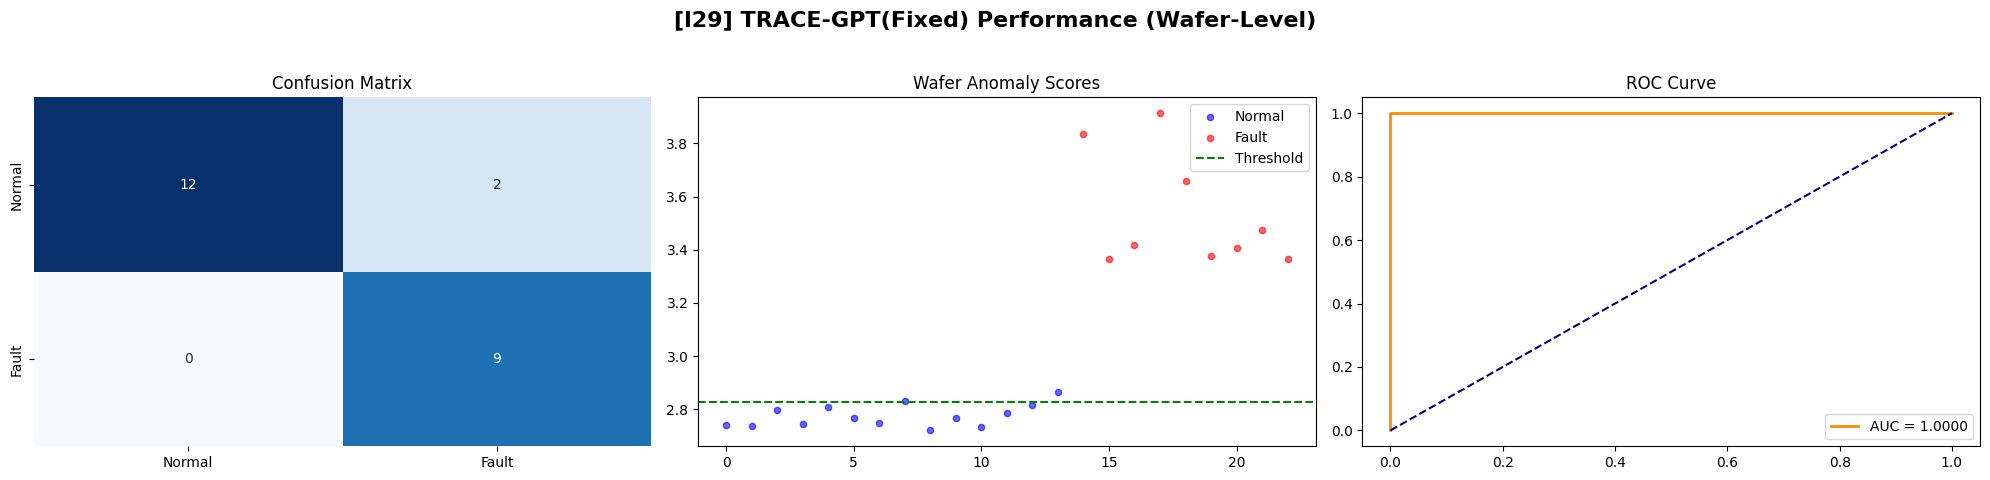


>>> Running TRACE-GPT on Experiment: l31

📊 [Data Setup] Experiment: l31
Training started...
Epoch [2] Loss: 2.5615
Epoch [4] Loss: 2.4639
Epoch [6] Loss: 2.3383
Epoch [8] Loss: 2.2477
Epoch [10] Loss: 2.1918
Epoch [12] Loss: 2.1523
Epoch [14] Loss: 2.1258
Epoch [16] Loss: 2.1031
Epoch [18] Loss: 2.0824
Epoch [20] Loss: 2.0659
Epoch [22] Loss: 2.0399
Epoch [24] Loss: 2.0223
Epoch [26] Loss: 2.0035
Epoch [28] Loss: 1.9837
Epoch [30] Loss: 1.9675
Epoch [32] Loss: 1.9455
Epoch [34] Loss: 1.9234
Epoch [36] Loss: 1.9088
Epoch [38] Loss: 1.8971
Epoch [40] Loss: 1.8622
Epoch [42] Loss: 1.8440
Epoch [44] Loss: 1.8195
Epoch [46] Loss: 1.8012
Epoch [48] Loss: 1.7823
Epoch [50] Loss: 1.7564
Calculating Train Scores for Thresholding...
   * Train Score Mean: 2.0194, Std: 0.0568
   * Fixed 3-Sigma Threshold: 2.1897
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [TRACE-GPT(Fixed) - l31] Wafer-Level Summary (Unsupervised)
   - AUROC          : 1.0000
   - F1-Score       : 0.44

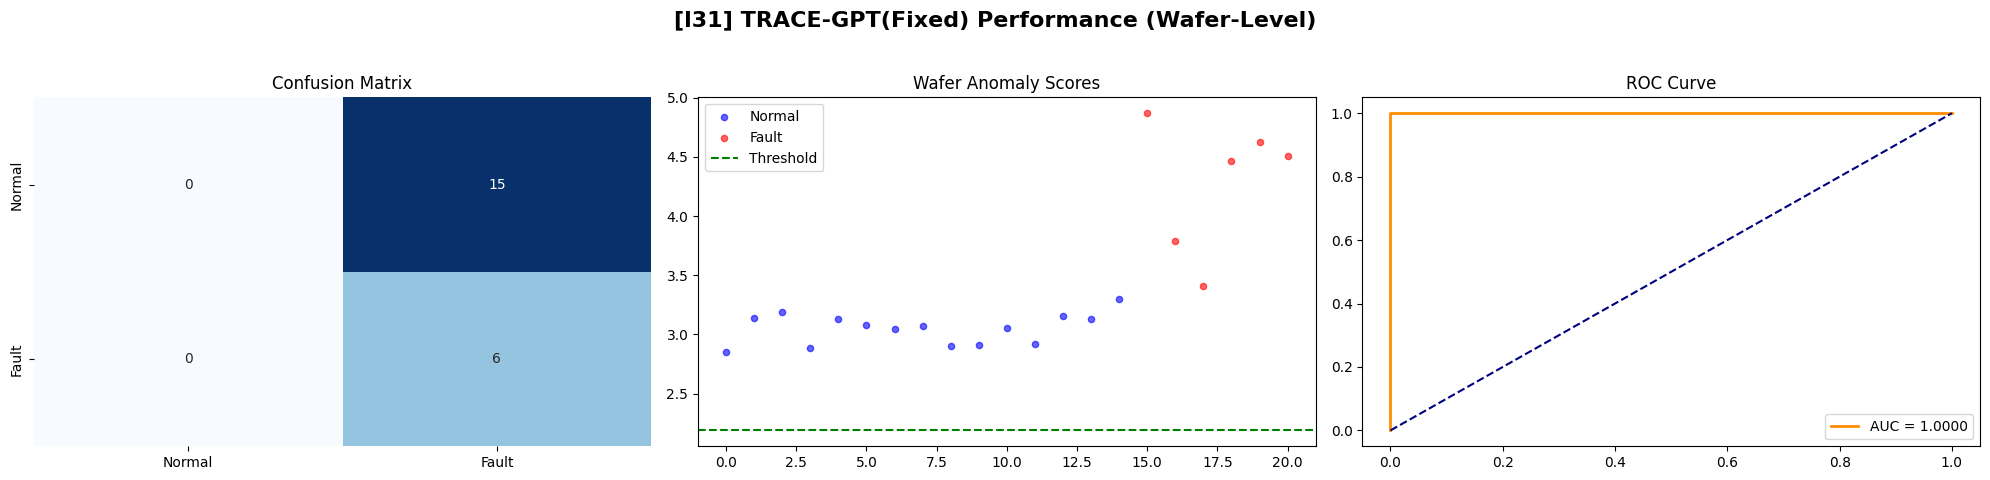


>>> Running TRACE-GPT on Experiment: l33

📊 [Data Setup] Experiment: l33
Training started...
Epoch [2] Loss: 2.5817
Epoch [4] Loss: 2.4158
Epoch [6] Loss: 2.3302
Epoch [8] Loss: 2.2820
Epoch [10] Loss: 2.2329
Epoch [12] Loss: 2.1958
Epoch [14] Loss: 2.1633
Epoch [16] Loss: 2.1248
Epoch [18] Loss: 2.1014
Epoch [20] Loss: 2.0866
Epoch [22] Loss: 2.0677
Epoch [24] Loss: 2.0486
Epoch [26] Loss: 2.0403
Epoch [28] Loss: 2.0113
Epoch [30] Loss: 1.9893
Epoch [32] Loss: 1.9674
Epoch [34] Loss: 1.9556
Epoch [36] Loss: 1.9230
Epoch [38] Loss: 1.9048
Epoch [40] Loss: 1.8837
Epoch [42] Loss: 1.8635
Epoch [44] Loss: 1.8422
Epoch [46] Loss: 1.8202
Epoch [48] Loss: 1.8010
Epoch [50] Loss: 1.7818
Calculating Train Scores for Thresholding...
   * Train Score Mean: 2.1147, Std: 0.0620
   * Fixed 3-Sigma Threshold: 2.3006
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [TRACE-GPT(Fixed) - l33] Wafer-Level Summary (Unsupervised)
   - AUROC          : 1.0000
   - F1-Score       : 0.44

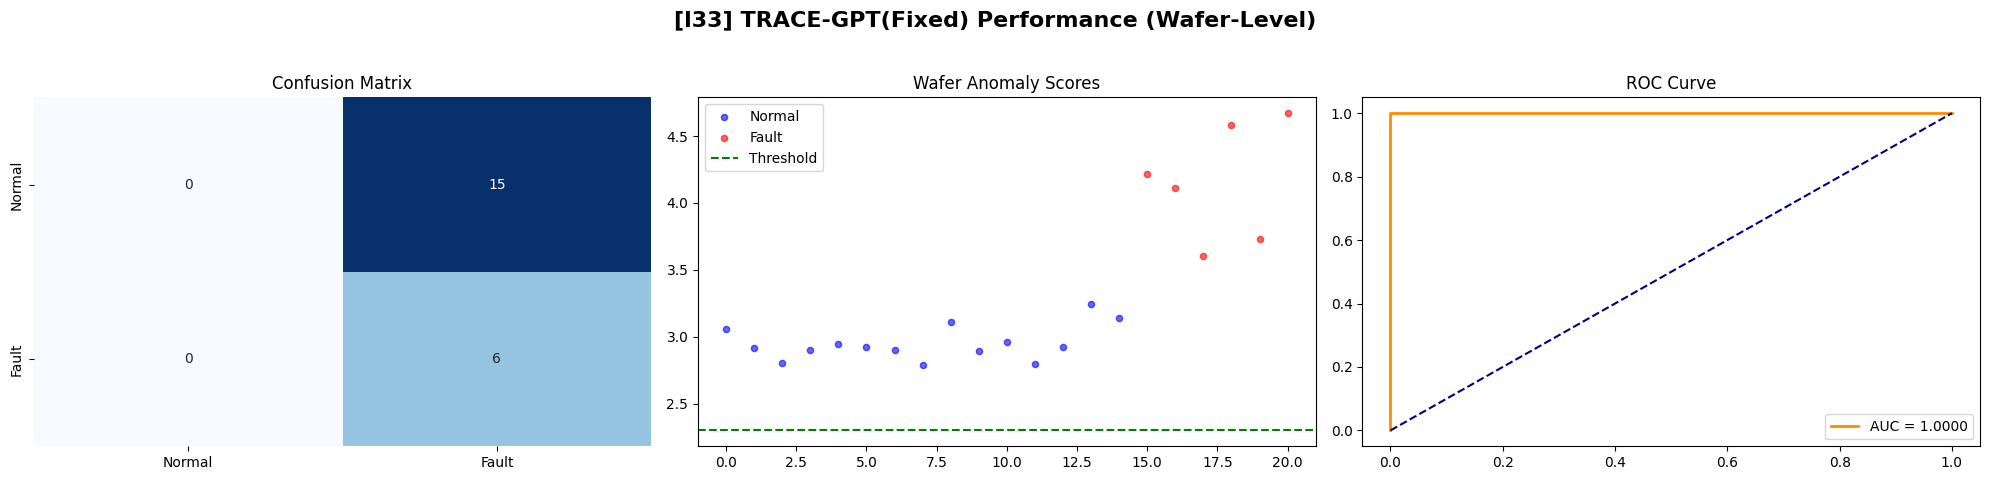


✅ All experiments finished.
{'l29': {'AUC': np.float64(1.0), 'F1': 0.9}, 'l31': {'AUC': np.float64(1.0), 'F1': 0.4444444444444444}, 'l33': {'AUC': np.float64(1.0), 'F1': 0.4444444444444444}}


In [14]:
# ==========================================
# 5. 메인 실행 루프
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 하이퍼파라미터
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
D_MODEL = 64
RESOLUTION = 100
SIGMA_MULTIPLIER = 3

results = {}
target_experiments = ['l29', 'l31', 'l33']

for exp_id in target_experiments:
    # 데이터셋 존재 여부 확인
    if exp_id not in datasets:
        print(f"Skipping {exp_id}: Dataset not found.")
        continue

    print(f"\n>>> Running TRACE-GPT on Experiment: {exp_id}")

    # 1. 데이터 로드
    train_loader, (test_norm, ids_norm), (test_fault, ids_fault) = get_data_loaders(exp_id, datasets, BATCH_SIZE)

    # 2. 모델 초기화
    num_sensors = test_norm.shape[2]
    seq_len_input = test_norm.shape[1] # 32

    model = TRACE_GPT(
        num_sensors=num_sensors,
        seq_len=seq_len_input - 1, # Next token prediction이므로 길이는 31
        d_model=D_MODEL,
        resolution=RESOLUTION
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 3. 학습
    print("Training started...")
    for epoch in range(NUM_EPOCHS):
        train_trace_gpt(model, train_loader, optimizer, epoch, device, RESOLUTION)

    # -----------------------------------------------------------
    # 4. 임계값(Threshold) 설정 (Train 데이터 통계치 활용)
    # -----------------------------------------------------------
    print("Calculating Train Scores for Thresholding...")
    # train_loader에서 텐서를 추출하여 Score 계산
    train_tensor = train_loader.dataset.tensors[0]
    train_window_scores = calculate_window_scores(model, train_tensor, device, BATCH_SIZE, RESOLUTION)

    # Train Score를 Wafer 단위로 집계
    ids_train = datasets[exp_id]['ids_train']
    _, train_wafer_scores = aggregate_wafer_scores(train_window_scores, ids_train, method='max')

    # Train 분포의 평균과 표준편차 계산
    train_mean = np.mean(train_wafer_scores)
    train_std = np.std(train_wafer_scores)

    # 3-Sigma 임계값 설정
    fixed_threshold = train_mean + (SIGMA_MULTIPLIER * train_std)

    print(f"   * Train Score Mean: {train_mean:.4f}, Std: {train_std:.4f}")
    print(f"   * Fixed 3-Sigma Threshold: {fixed_threshold:.4f}")

    # -----------------------------------------------------------
    # 5. 추론 (Test Data Window Score)
    # -----------------------------------------------------------
    print("Calculating Test Window Scores...")
    norm_window_scores = calculate_window_scores(model, test_norm, device, BATCH_SIZE, RESOLUTION)

    if len(test_fault) > 0:
        fault_window_scores = calculate_window_scores(model, test_fault, device, BATCH_SIZE, RESOLUTION)
    else:
        fault_window_scores = np.array([])

    # -----------------------------------------------------------
    # 6. 집계 (Wafer Aggregation)
    # -----------------------------------------------------------
    print("Aggregating Test Wafer Scores...")
    _, norm_wafer_scores = aggregate_wafer_scores(norm_window_scores, ids_norm, method='max')
    norm_labels = np.zeros(len(norm_wafer_scores))

    if len(fault_window_scores) > 0:
        _, fault_wafer_scores = aggregate_wafer_scores(fault_window_scores, ids_fault, method='max')
        fault_labels = np.ones(len(fault_wafer_scores))
    else:
        fault_wafer_scores = np.array([])
        fault_labels = np.array([])

    final_scores = np.concatenate([norm_wafer_scores, fault_wafer_scores])
    final_labels = np.concatenate([norm_labels, fault_labels])

    # -----------------------------------------------------------
    # 7. 평가
    # -----------------------------------------------------------
    auc_score, f1 = evaluate_performance_fixed_threshold(
        "TRACE-GPT(Fixed)", exp_id, final_scores, final_labels, fixed_threshold
    )
    results[exp_id] = {'AUC': auc_score, 'F1': f1}

print("\n✅ All experiments finished.")
print(results)

# **VTimesNet**

## **2. 파라미터 설정, 데이터 로드, 데이터셋 분리**

- 실험 별로 나누어서 데이터셋 구성

In [15]:
# ==========================================
# 1. 라이브러리 및 환경 설정 (필수)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, f1_score
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
import warnings


# ==========================================
# 2. 데이터 로드
# ==========================================
file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx"

if os.path.exists(file_path):
    print(f"Loading data from: {file_path}")
    if file_path.endswith('.xlsx'):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path)
else:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    df = pd.DataFrame()

# 센서 컬럼 정의
sensor_cols = [
    'BCl3 Flow', 'Cl2 Flow', 'RF Btm Pwr', 'RF Btm Rfl Pwr', 'Endpt A',
    'He Press', 'Pressure', 'RF Tuner', 'RF Load', 'RF Phase Err',
    'RF Pwr', 'RF Impedance', 'TCP Tuner', 'TCP Phase Err',
    'TCP Impedance', 'TCP Top Pwr', 'TCP Rfl Pwr', 'TCP Load', 'Vat Valve'
]

# ==========================================
# 3. 데이터 전처리 함수
# ==========================================
"""
    Wafer_ID 별로 슬라이딩 윈도우를 적용하고,
    각 윈도우가 어떤 Wafer에 속하는지 ID 리스트를 함께 반환합니다.
"""
def create_sequences_with_ids(df_target, wafer_col, sensor_cols, seq_len, scaler=None, is_train=True):

    # 1. 데이터 추출
    data_values = df_target[sensor_cols].values

    # 2. 스케일링 (Train 통계로만 Scale)
    if is_train:
        if scaler is None:
            scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(data_values)
    else:
        if scaler is None:
            raise ValueError("Test mode requires a fitted scaler from training data.")
        data_scaled = scaler.transform(data_values)

    # 스케일링된 데이터를 다시 DataFrame으로 매핑 (ID 그룹핑 용도)
    df_scaled = pd.DataFrame(data_scaled, columns=sensor_cols, index=df_target.index)
    df_scaled[wafer_col] = df_target[wafer_col].values

    all_sequences = []
    all_wafer_ids = [] # [NEW] 각 윈도우의 소스 Wafer ID를 저장할 리스트

    unique_wafers = df_scaled[wafer_col].unique()

    for wafer in unique_wafers:
        # 특정 Wafer 데이터 추출
        wafer_data = df_scaled[df_scaled[wafer_col] == wafer][sensor_cols].values

        # 데이터 길이가 윈도우보다 작으면 스킵
        if len(wafer_data) < seq_len:
            continue

        # 슬라이딩 윈도우 생성
        for i in range(len(wafer_data) - seq_len + 1):
            window = wafer_data[i : i + seq_len]

            all_sequences.append(window)
            all_wafer_ids.append(wafer) # [NEW] 현재 윈도우의 Wafer ID 저장

    if len(all_sequences) == 0:
        return np.array([]), np.array([]), scaler

    return np.array(all_sequences), np.array(all_wafer_ids), scaler

# ==========================================
# 4. 데이터셋 구성 및 저장
# ==========================================
experiments = ['l29', 'l31', 'l33']
datasets = {}
SEQ_LEN = 64

# 학습 데이터 비율 설정
TRAIN_RATIO = 0.6

print(f"\n--- Preprocessing Data (Train Ratio: {TRAIN_RATIO*100}%) ---")

for exp_id in experiments:
    print(f"\nProcessing Experiment: {exp_id}")

    # 1. 실험 데이터 필터링
    exp_df = df[df['Wafer_ID'].str.contains(exp_id, case=False, na=False)]
    if exp_df.empty:
        continue

    # 2. Train / Test Split (Wafer ID 기준)
    normal_wafer_ids = exp_df[exp_df['Label'] == 'Normal']['Wafer_ID'].unique()
    fault_wafer_ids = exp_df[exp_df['Label'] == 'Fault']['Wafer_ID'].unique()

    # [수정] 비율 적용 (Normal Wafer만 분할)
    n_train = int(len(normal_wafer_ids) * TRAIN_RATIO)

    train_ids = normal_wafer_ids[:n_train]
    test_norm_ids = normal_wafer_ids[n_train:]

    # ID 기반 데이터프레임 분할
    train_df = exp_df[exp_df['Wafer_ID'].isin(train_ids)]
    test_norm_df = exp_df[exp_df['Wafer_ID'].isin(test_norm_ids)]
    test_fault_df = exp_df[exp_df['Wafer_ID'].isin(fault_wafer_ids)]

    print(f"  - Total Normal: {len(normal_wafer_ids)}")
    print(f"  -> Train Normal : {len(train_ids)} ({TRAIN_RATIO*100:.0f}%)")
    print(f"  -> Test Normal  : {len(test_norm_ids)} ({(1-TRAIN_RATIO)*100:.0f}%)")
    print(f"  -> Test Fault   : {len(fault_wafer_ids)} (100%)")

    # 3. 시퀀스 생성 (X, Wafer_ID 반환)
    # (1) Train: Scaler 학습 (Fit)
    X_train, y_train_ids, scaler = create_sequences_with_ids(
        train_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=None, is_train=True
    )

    # (2) Test Normal: Scaler 적용 (Transform)
    X_test_norm, y_test_norm_ids, _ = create_sequences_with_ids(
        test_norm_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=scaler, is_train=False
    )

    # (3) Test Fault: Scaler 적용 (Transform)
    if not test_fault_df.empty:
        X_test_fault, y_test_fault_ids, _ = create_sequences_with_ids(
            test_fault_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=scaler, is_train=False
        )
    else:
        X_test_fault, y_test_fault_ids = np.array([]), np.array([])

    # 4. Dictionary에 저장
    datasets[exp_id] = {
        'X_train': X_train,
        'X_test_norm': X_test_norm,
        'X_test_fault': X_test_fault,
        'ids_train': y_train_ids,
        'ids_test_norm': y_test_norm_ids,
        'ids_test_fault': y_test_fault_ids,
        'scaler': scaler
    }

print("\n✅ Data preprocessing with new ratio completed.")

Loading data from: /content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx

--- Preprocessing Data (Train Ratio: 60.0%) ---

Processing Experiment: l29
  - Total Normal: 34
  -> Train Normal : 20 (60%)
  -> Test Normal  : 14 (40%)
  -> Test Fault   : 9 (100%)

Processing Experiment: l31
  - Total Normal: 37
  -> Train Normal : 22 (60%)
  -> Test Normal  : 15 (40%)
  -> Test Fault   : 6 (100%)

Processing Experiment: l33
  - Total Normal: 37
  -> Train Normal : 22 (60%)
  -> Test Normal  : 15 (40%)
  -> Test Fault   : 6 (100%)

✅ Data preprocessing with new ratio completed.


## **3. 함수 정의**

In [16]:
# ==========================================
# 3. 유틸리티 함수 (데이터 로드, 집계, 시각화)
# ==========================================
def get_data_loaders(exp_id, datasets_dict, batch_size=32):
    print(f"\n📊 [Data Setup] Experiment: {exp_id}")
    data = datasets_dict[exp_id]

    # 데이터 추출
    X_train = data['X_train']
    X_test_norm = data['X_test_norm']
    ids_test_norm = data['ids_test_norm']
    X_test_fault = data['X_test_fault']
    ids_test_fault = data['ids_test_fault']

    # Tensor 변환
    train_tensor = torch.FloatTensor(X_train)
    test_norm_tensor = torch.FloatTensor(X_test_norm)

    if len(X_test_fault) > 0:
        test_fault_tensor = torch.FloatTensor(X_test_fault)
    else:
        test_fault_tensor = torch.FloatTensor([])

    # DataLoader (Train only)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    return train_loader, (test_norm_tensor, ids_test_norm), (test_fault_tensor, ids_test_fault)

def aggregate_wafer_scores(window_scores, wafer_ids, method='max'):
    # DataFrame핑하여 GroupBy 연산
    df_temp = pd.DataFrame({'Wafer_ID': wafer_ids, 'Score': window_scores})

    if method == 'max':
        grouped = df_temp.groupby('Wafer_ID')['Score'].max()
    else:
        grouped = df_temp.groupby('Wafer_ID')['Score'].mean()

    return grouped.index.values, grouped.values

def visualize_results(model_name, exp_id, scores, labels, threshold):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plt.suptitle(f"[{exp_id}] {model_name} Performance (Wafer-Level)", fontsize=16, fontweight='bold')

    # Confusion Matrix
    preds = (scores > threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=['Normal', 'Fault'], yticklabels=['Normal', 'Fault'])
    axes[0].set_title("Confusion Matrix")

    # Scatter Plot (Wafer Scores)
    normal_idx = np.where(labels == 0)[0]
    fault_idx = np.where(labels == 1)[0]

    axes[1].scatter(normal_idx, scores[normal_idx], color='blue', label='Normal', alpha=0.6, s=20)
    axes[1].scatter(fault_idx, scores[fault_idx], color='red', label='Fault', alpha=0.6, s=20)
    axes[1].axhline(y=threshold, color='green', linestyle='--', label='Threshold')
    axes[1].set_title("Wafer Anomaly Scores")
    axes[1].legend()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[2].set_title("ROC Curve")
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def evaluate_performance_fixed_threshold(model_name, exp_id, scores, labels, threshold):
    # 1. 고정된 임계값을 기준으로 이상 여부 판별 (크면 1: Fault, 작으면 0: Normal)
    preds = (scores > threshold).astype(int)

    # 2. F1-Score 계산 (더 이상 최적의 값을 찾지 않음)
    f1 = f1_score(labels, preds)

    # 3. AUROC 계산 (AUC는 임계값과 무관하게 모델의 분류 잠재력을 보여줌)
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    print(f"\n📌 [{model_name} - {exp_id}] Wafer-Level Summary (Unsupervised)")
    print(f"   - AUROC          : {roc_auc:.4f}")
    print(f"   - F1-Score       : {f1:.4f} (at Fixed Threshold: {threshold:.6f})")

    # 시각화 함수 호출
    visualize_results(model_name, exp_id, scores, labels, threshold)

    return roc_auc, f1

## **4. 모델 구현**

In [17]:
import torch
import torch.nn as nn
import torch.fft
import torch.nn.functional as F

class DCM(nn.Module):
    """
    Dilated Convolutional Module (2D 기반 다중 스케일 특징 추출)
    논문: 팽창률(Dilation rate) 2, 커널 크기 {1,2,3,4,5,6} 병렬 적용 [cite: 127]
    """
    def __init__(self, in_channels):
        super(DCM, self).__init__()
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels, in_channels, kernel_size=k, padding='same', dilation=2)
            for k in range(1, 7)
        ])

    def forward(self, x):
        # 다중 스케일 특징 F1 ~ F6 반환
        return [conv(x) for conv in self.convs]

class GLGM(nn.Module):
    """
    Global-Local-Global Fusion Module
    논문: Global-Local 경로와 Local-Global 경로를 통한 양방향 정보 융합 [cite: 170, 174, 179]
    """
    def __init__(self, channels):
        super(GLGM, self).__init__()
        # 논문 구조상 단순화를 위해 1x1 Conv로 스케일 융합을 모사 (실제 구현 시 해상도 조절 가능)
        self.fusion_conv = nn.Conv2d(channels * 6, channels, kernel_size=3, padding=1)

    def forward(self, features):
        # 6개의 다중 스케일 특징(F1~F6)을 양방향 융합 (단순화된 병합 구조)
        concat_features = torch.cat(features, dim=1)
        out = self.fusion_conv(concat_features)
        return out

class CBAM(nn.Module):
    """
    Convolutional Block Attention Module
    논문: 채널 어텐션과 공간 어텐션을 순차적으로 적용 [cite: 184, 185, 190]
    """
    def __init__(self, channels):
        super(CBAM, self).__init__()
        # Channel Attention [cite: 186, 187, 188]
        self.ca_mlp = nn.Sequential(
            nn.Conv2d(channels, channels // 2, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // 2, channels, 1, bias=False)
        )
        self.ca_sigmoid = nn.Sigmoid()

        # Spatial Attention [cite: 191, 192]
        self.sa_conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sa_sigmoid = nn.Sigmoid()

    def forward(self, x):
        # 1. Channel Attention
        avg_out = self.ca_mlp(F.adaptive_avg_pool2d(x, 1))
        max_out = self.ca_mlp(F.adaptive_max_pool2d(x, 1))
        ca_weight = self.ca_sigmoid(avg_out + max_out)
        x = x * ca_weight

        # 2. Spatial Attention
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        max_pool, _ = torch.max(x, dim=1, keepdim=True)
        sa_weight = self.sa_sigmoid(self.sa_conv(torch.cat([avg_pool, max_pool], dim=1)))
        x = x * sa_weight
        return x

class TimesPlusBlock(nn.Module):
    """
    V-TimesNet의 핵심 블록: 1D -> 2D 변환 -> 비전 모듈(DCM, GLGM, CBAM) -> 1D 복원 [cite: 96, 116, 119]
    """
    def __init__(self, d_model, k=3):
        super(TimesPlusBlock, self).__init__()
        self.k = k
        self.dcm = DCM(d_model)
        self.glgm = GLGM(d_model)
        self.cbam = CBAM(d_model)

    def forward(self, x):
        B, C, T = x.size()
        x_fft = torch.fft.rfft(x, dim=-1)
        ampls = torch.abs(x_fft)

        avg_ampls = ampls.mean(dim=0).mean(dim=0)
        topk_ampls, topk_indices = torch.topk(avg_ampls, k=self.k)

        res = []
        for idx in topk_indices:
            freq = idx.item()
            period = 1 if freq == 0 else T // freq

            pad_len = 0 if T % period == 0 else period - (T % period)
            x_pad = F.pad(x, (0, pad_len)) if pad_len > 0 else x

            # 1. 1D to 2D Reshape [cite: 84]
            x_2d = x_pad.view(B, C, -1, period)

            # 2. Vision Modules (DCM -> GLGM -> CBAM) [cite: 96]
            dcm_out = self.dcm(x_2d)
            glgm_out = self.glgm(dcm_out)
            out_2d = self.cbam(glgm_out)

            # 3. 2D to 1D Reshape [cite: 96]
            out_1d = out_2d.view(B, C, -1)
            if pad_len > 0:
                out_1d = out_1d[..., :-pad_len]
            res.append(out_1d)

        res = torch.stack(res, dim=-1)
        weights = torch.softmax(topk_ampls, dim=-1).unsqueeze(0).unsqueeze(0).unsqueeze(0)
        out = torch.sum(res * weights.to(x.device), dim=-1)

        return out + x # Residual Connection [cite: 79]

class VTimesNet(nn.Module):
    def __init__(self, seq_len, n_features, d_model=4, k=3, num_layers=3, fcn_dim=16):
        super(VTimesNet, self).__init__()
        self.embedding = nn.Linear(n_features, d_model)

        # P개의 TimesPlus 블록 적층 (논문 기준 3개) [cite: 73, 266]
        self.layers = nn.ModuleList([TimesPlusBlock(d_model, k=k) for _ in range(num_layers)])

        # Reconstruction Head: FCN dimension 반영 [cite: 379, 380]
        self.projection = nn.Sequential(
            nn.Linear(d_model, fcn_dim),
            nn.GELU(),
            nn.Linear(fcn_dim, n_features)
        )

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1) # [B, d_model, T]
        for layer in self.layers:
            x = layer(x)
        x = x.permute(0, 2, 1) # [B, T, d_model]
        x = self.projection(x)
        return x


import time
import torch.optim as optim

def train_vtimesnet_epoch(model, train_loader, optimizer, device):
    """1 Epoch 동안 V-TimesNet을 학습하는 함수"""
    model.train()
    total_loss = 0
    criterion = nn.MSELoss()

    for batch in train_loader:
        x_batch = batch[0].to(device)

        optimizer.zero_grad()
        output = model(x_batch)

        # 재구성 손실 (Reconstruction Loss) 계산
        loss = criterion(output, x_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def calculate_window_scores_vtimesnet(model, tensor_data, device, batch_size=32):
    """
    배치 단위로 V-TimesNet 추론을 진행하여 Window-level Anomaly Score(MSE) 계산
    (OOM 방지를 위해 DataLoader 사용)
    """
    model.eval()
    scores = []
    dataset = TensorDataset(tensor_data)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for batch in loader:
            x_batch = batch[0].to(device)
            reconstruction = model(x_batch)

            # Sample 단위 MSE 계산: (Batch, Seq_len, Features) -> (Batch)
            loss = torch.mean((x_batch - reconstruction) ** 2, dim=[1, 2])
            scores.extend(loss.cpu().numpy())

    return np.array(scores)

## **5. 학습 및 추론**

Using device: cuda

>>> Running V-TimesNet on Experiment: l29

📊 [Data Setup] Experiment: l29
Training started...
  - Epoch [10/50], Loss: 0.009484
  - Epoch [20/50], Loss: 0.005204
  - Epoch [30/50], Loss: 0.003796
  - Epoch [40/50], Loss: 0.003040
  - Epoch [50/50], Loss: 0.002459
Calculating Train Scores for Thresholding...
   * Train Score Mean: 0.0034, Std: 0.0005
   * Fixed 3-Sigma Threshold: 0.0050
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [V-TimesNet(Fixed) - l29] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.9286
   - F1-Score       : 0.7778 (at Fixed Threshold: 0.005015)


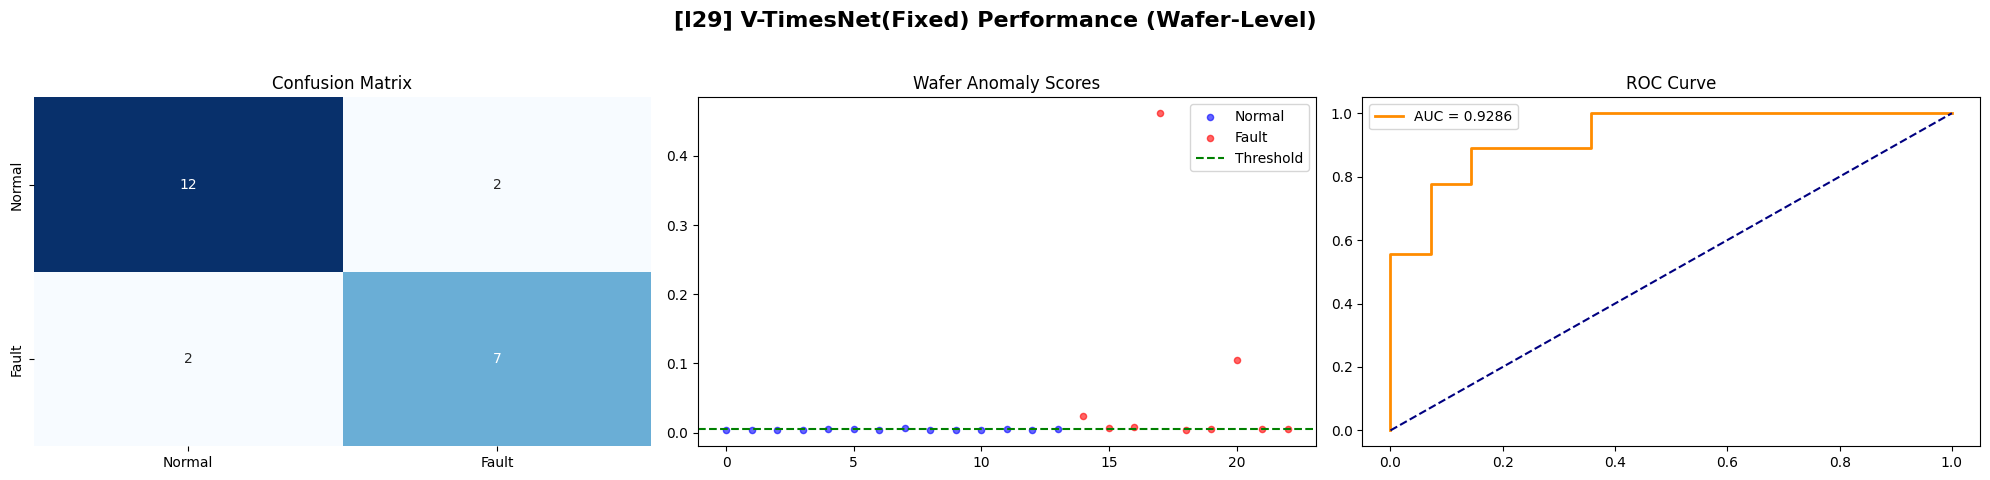


>>> Running V-TimesNet on Experiment: l31

📊 [Data Setup] Experiment: l31
Training started...
  - Epoch [10/50], Loss: 0.009626
  - Epoch [20/50], Loss: 0.004233
  - Epoch [30/50], Loss: 0.002770
  - Epoch [40/50], Loss: 0.002389
  - Epoch [50/50], Loss: 0.002142
Calculating Train Scores for Thresholding...
   * Train Score Mean: 0.0030, Std: 0.0003
   * Fixed 3-Sigma Threshold: 0.0039
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [V-TimesNet(Fixed) - l31] Wafer-Level Summary (Unsupervised)
   - AUROC          : 1.0000
   - F1-Score       : 0.8333 (at Fixed Threshold: 0.003912)


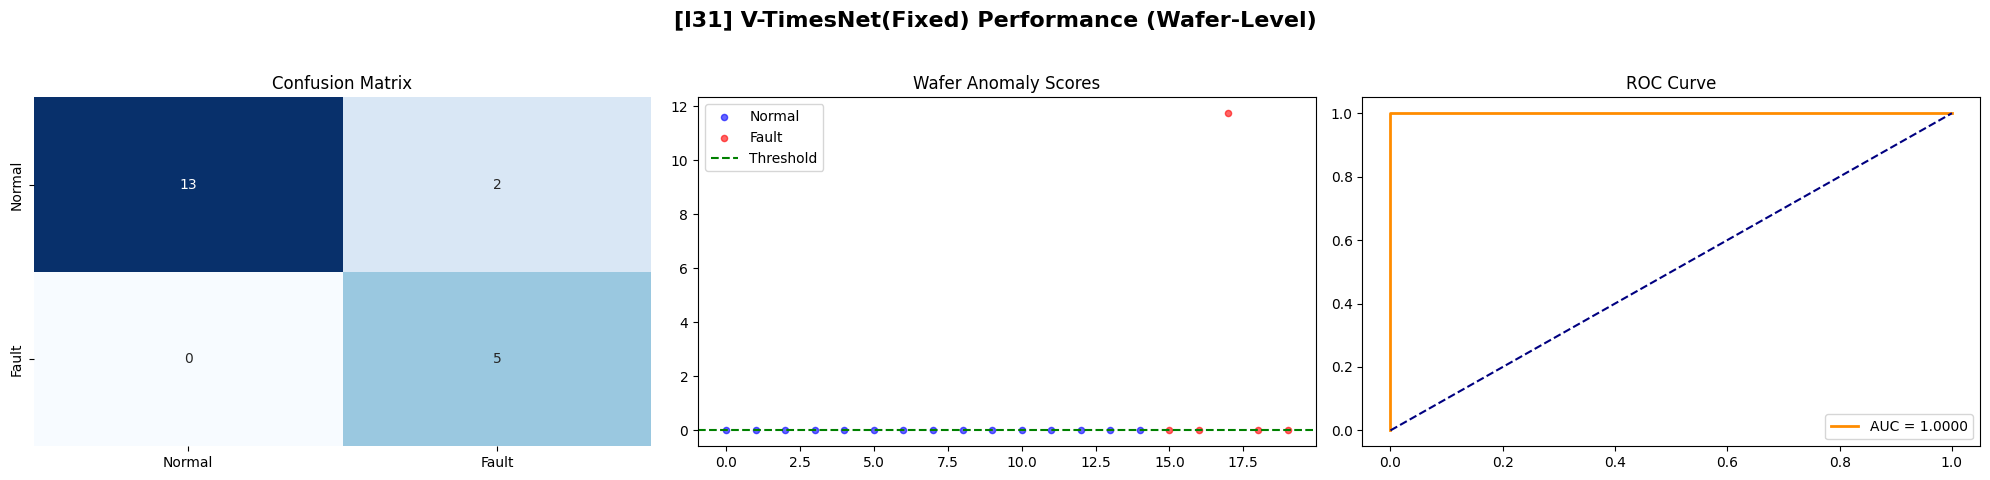


>>> Running V-TimesNet on Experiment: l33

📊 [Data Setup] Experiment: l33
Training started...
  - Epoch [10/50], Loss: 0.007201
  - Epoch [20/50], Loss: 0.002970
  - Epoch [30/50], Loss: 0.001929
  - Epoch [40/50], Loss: 0.001523
  - Epoch [50/50], Loss: 0.001353
Calculating Train Scores for Thresholding...
   * Train Score Mean: 0.0018, Std: 0.0002
   * Fixed 3-Sigma Threshold: 0.0025
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [V-TimesNet(Fixed) - l33] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.9444
   - F1-Score       : 0.8000 (at Fixed Threshold: 0.002519)


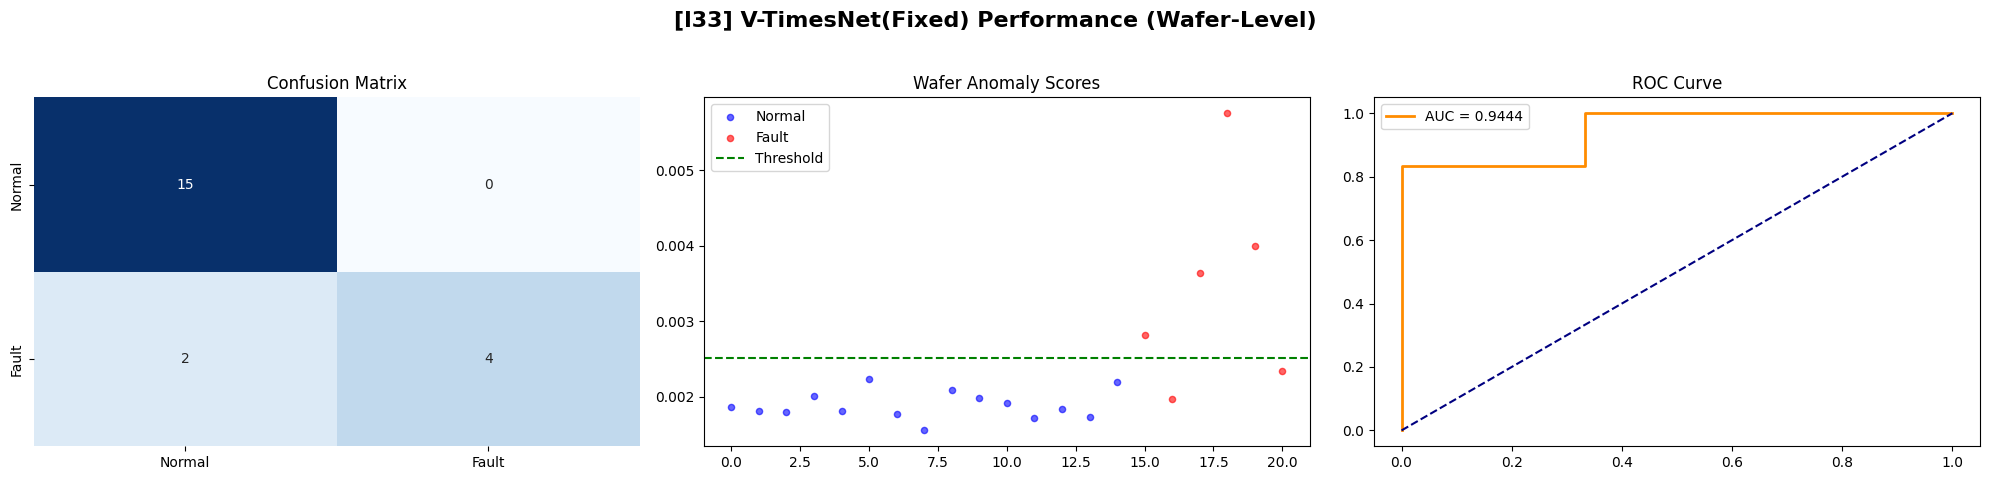


✅ All experiments finished.
 - [l29] AUROC: 0.9286 | F1-Score: 0.7778
 - [l31] AUROC: 1.0000 | F1-Score: 0.8333
 - [l33] AUROC: 0.9444 | F1-Score: 0.8000


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 하이퍼파라미터
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
D_MODEL = 64
TOP_K = 3               # V-TimesNet 전용: 상위 K개 주파수
SIGMA_MULTIPLIER = 3    # 3-Sigma 임계값

results = {}
target_experiments = ['l29', 'l31', 'l33']

for exp_id in target_experiments:
    # 데이터셋 존재 여부 확인
    if exp_id not in datasets:
        print(f"Skipping {exp_id}: Dataset not found.")
        continue

    print(f"\n>>> Running V-TimesNet on Experiment: {exp_id}")

    # 1. 데이터 로드
    train_loader, (test_norm, ids_norm), (test_fault, ids_fault) = get_data_loaders(exp_id, datasets, BATCH_SIZE)

    # 2. 모델 초기화
    num_sensors = test_norm.shape[2]
    seq_len_input = test_norm.shape[1]

    model = VTimesNet(
        seq_len=seq_len_input,
        n_features=num_sensors,
        d_model=D_MODEL,
        k=TOP_K
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 3. 학습
    print("Training started...")
    for epoch in range(NUM_EPOCHS):
        avg_loss = train_vtimesnet_epoch(model, train_loader, optimizer, device)
        # 10 에폭마다 진행상황 출력
        if (epoch + 1) % 10 == 0:
            print(f"  - Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {avg_loss:.6f}")

    # -----------------------------------------------------------
    # 4. 임계값(Threshold) 설정 (Train 데이터 통계치 활용)
    # -----------------------------------------------------------
    print("Calculating Train Scores for Thresholding...")
    train_tensor = train_loader.dataset.tensors[0]
    train_window_scores = calculate_window_scores_vtimesnet(model, train_tensor, device, BATCH_SIZE)

    # Train Score를 Wafer 단위로 집계
    ids_train = datasets[exp_id]['ids_train']
    _, train_wafer_scores = aggregate_wafer_scores(train_window_scores, ids_train, method='max')

    # Train 분포의 평균과 표준편차 계산
    train_mean = np.mean(train_wafer_scores)
    train_std = np.std(train_wafer_scores)

    # 3-Sigma 임계값 설정
    fixed_threshold = train_mean + (SIGMA_MULTIPLIER * train_std)

    print(f"   * Train Score Mean: {train_mean:.4f}, Std: {train_std:.4f}")
    print(f"   * Fixed 3-Sigma Threshold: {fixed_threshold:.4f}")

    # -----------------------------------------------------------
    # 5. 추론 (Test Data Window Score)
    # -----------------------------------------------------------
    print("Calculating Test Window Scores...")
    norm_window_scores = calculate_window_scores_vtimesnet(model, test_norm, device, BATCH_SIZE)

    if len(test_fault) > 0:
        fault_window_scores = calculate_window_scores_vtimesnet(model, test_fault, device, BATCH_SIZE)
    else:
        fault_window_scores = np.array([])

    # -----------------------------------------------------------
    # 6. 집계 (Wafer Aggregation)
    # -----------------------------------------------------------
    print("Aggregating Test Wafer Scores...")
    _, norm_wafer_scores = aggregate_wafer_scores(norm_window_scores, ids_norm, method='max')
    norm_labels = np.zeros(len(norm_wafer_scores))

    if len(fault_window_scores) > 0:
        _, fault_wafer_scores = aggregate_wafer_scores(fault_window_scores, ids_fault, method='max')
        fault_labels = np.ones(len(fault_wafer_scores))
    else:
        fault_wafer_scores = np.array([])
        fault_labels = np.array([])

    final_scores = np.concatenate([norm_wafer_scores, fault_wafer_scores])
    final_labels = np.concatenate([norm_labels, fault_labels])

    # -----------------------------------------------------------
    # 7. 평가
    # -----------------------------------------------------------
    if len(np.unique(final_labels)) > 1:
        auc_score, f1 = evaluate_performance_fixed_threshold(
            "V-TimesNet(Fixed)", exp_id, final_scores, final_labels, fixed_threshold
        )
        results[exp_id] = {'AUC': auc_score, 'F1': f1}
    else:
        print(f"⚠️ [{exp_id}] Evaluation skipped: Missing either normal or fault test data.")

print("\n✅ All experiments finished.")
for exp, res in results.items():
    print(f" - [{exp}] AUROC: {res['AUC']:.4f} | F1-Score: {res['F1']:.4f}")